In [1]:
from shapely.geometry import Polygon
import numpy as np
import cv2
import matplotlib.pyplot as plt
import json
import easyocr
import os
os.chdir(r"C:\Users\Power Media\Documents\@ Fac\2024-2025 M2 HN Chartes\Python\evaluation")

In [7]:
#FONCTIONS

#IoU
def compute_iou(poly1_coords, poly2_coords):
    poly1 = Polygon(poly1_coords)
    poly2 = Polygon(poly2_coords)

    if not poly1.is_valid or not poly2.is_valid:
        return 0.0

    inter = poly1.intersection(poly2).area
    union = poly1.union(poly2).area
    return inter / union if union > 0 else 0.0
#Matching predictions / gt
def match_predictions(gt_polys, pred_polys, iou_threshold=0.5):
    matched_gt = set()
    matched_pred = set()
    ious = []

    for i, gt in enumerate(gt_polys):
        best_iou = 0
        best_j = -1
        for j, pred in enumerate(pred_polys):
            if j in matched_pred:
                continue
            iou = compute_iou(gt, pred)
            if iou > best_iou:
                best_iou = iou
                best_j = j
        if best_iou >= iou_threshold:
            matched_gt.add(i)
            matched_pred.add(best_j)
            ious.append(best_iou)

    tp = len(matched_gt)
    fp = len(pred_polys) - len(matched_pred)
    fn = len(gt_polys) - len(matched_gt)

    return tp, fp, fn, ious
#Visualisation 
def plot_polygons(image_path, gt_entry, pred_entry):
    gt_polys = [vertices for vertices,_ in gt_entry]
    pred_polys = [vertices for vertices,_,_ in pred_entry]
    img = cv2.imread(image_path)
    if img is None:
        print("Image introuvable :", image_path)
        return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for poly in gt_polys:
        pts = np.array(poly, np.int32).reshape((-1, 1, 2))
        cv2.polylines(img, [pts], True, (0, 255, 0), 2)  # Vert : vérité terrain

    for poly in pred_polys:
        pts = np.array(poly, np.int32).reshape((-1, 1, 2))
        cv2.polylines(img, [pts], True, (255, 0, 0), 2)  # Bleu : prédiction

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()
#Evaluation globale
def evaluate_dataset(ground_truth, predictions, iou_threshold=0.5):
    total_tp = total_fp = total_fn = 0
    all_ious = []

    for image_name in ground_truth:
        gt_entries = ground_truth.get(image_name, [])
        pred_entries = predictions.get(image_name, [])
        gt_polys = [vertices for vertices,_ in gt_entries]
        pred_polys = [vertices for vertices,_,_ in pred_entries]

        tp, fp, fn, ious = match_predictions(gt_polys, pred_polys, iou_threshold)

        total_tp += tp
        total_fp += fp
        total_fn += fn
        all_ious.extend(ious)

    precision = total_tp / (total_tp + total_fp + 1e-6)
    recall = total_tp / (total_tp + total_fn + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)
    mean_iou = np.mean(all_ious) if all_ious else 0.0

    print("\n=== Résultats globaux ===")
    print(f"Précision     : {precision:.4f}")
    print(f"Rappel        : {recall:.4f}")
    print(f"F1-score      : {f1:.4f}")
    print(f"Mean IoU      : {mean_iou:.4f}")
    print(f"TP: {total_tp}, FP: {total_fp}, FN: {total_fn}")


# Prédiction par EasyOCR

In [ ]:
#Etablissement des prédictions avec easyOCR (peut prendre une vingtaine de minutes)
predictions=dict()
reader = easyocr.Reader(['fr']) 
for root, dirs, files in os.walk(f"ign/val"):
    for file in files:
        image_path=f"{root}/{file}"
        image = cv2.imread(image_path)
        results = reader.readtext(image)
        predictions[image_path]=results

def convert_numpy(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj)} is not JSON serializable")
with open(f"ign_pred.json","w") as file:
    json.dump(predictions, file, default=convert_numpy)

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


# Evaluation avec fonction personnelle

In [ ]:
#Mise en forme de la gt pour la fonction d'évaluation personnelle
with open(f'ign_val.json') as file:
    fullgt=json.load(file)
def transform(data):
    result = {}
    for item in data:
        image_name = item['image']
        items = []
        for group in item['groups']:
            for region in group:
                items.append((region['vertices'],region["text"]))
        result[image_name] = items
    return result
ground_truth=transform(fullgt)

In [ ]:
#Evaluation avec fonction personnelle
evaluate_dataset(ground_truth, predictions, iou_threshold=0.5)


=== Résultats globaux ===
Précision     : 0.8242
Rappel        : 0.2576
F1-score      : 0.3926
Mean IoU      : 0.7136
TP: 464, FP: 99, FN: 1337


## Résultats vec fonction d'évaluation personnelle
Précision     : 0.8242
Rappel        : 0.2576
F1-score      : 0.3926
Mean IoU      : 0.7136
TP: 464, FP: 99, FN: 1337

In [9]:
#Conversion de la prédiction pour la rendre accessible à la fonction d'évaluation fournie : 
converted = []

for image_path, annotations in predictions.items():
    image_entry = {
        "image": image_path,
        "groups": []
    }

    for ann in annotations:
        polygon, text, score = ann

        group = [{
            "vertices": polygon,
            "text": text,
            "illegible": False,
            "truncated": False
        }]
        
        image_entry["groups"].append(group)

    converted.append(image_entry)

# Sauvegarder dans un nouveau fichier
with open("ign_pred2.json", "w", encoding="utf-8") as f:
    json.dump(converted, f, ensure_ascii=False)

# Evaluation avec fonction officielle

In [ ]:
## installation : https://github.com/icdar-maptext/evaluation/tree/main?tab=readme-ov-file#conda-installation
! python eval.py --gt ign_val.json --pred ign_pred2.json --task det 

{'recall': 0.2821969696969697, 'precision': 0.8186813186813187, 'fscore': 0.419718309859155, 'tightness': 0.7140851052619319, 'quality': 0.2997145934761348, 'hmean': 0.4865790173543778}


## Résultats avec fonction officielle
{'recall': 0.2821969696969697, 'precision': 0.8186813186813187, 'fscore': 0.419718309859155, 'tightness': 0.7140851052619319, 'quality': 0.2997145934761348, 'hmean': 0.4865790173543778}

# Visualisation

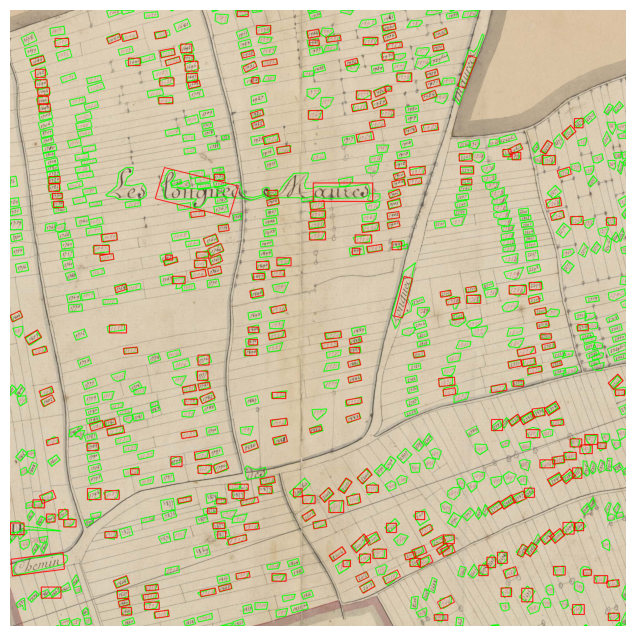

In [ ]:
#Afficher une image
image_name = "ign/val/000005.jpg"
plot_polygons(image_name, ground_truth[image_name], predictions[image_name])
